<a href="https://colab.research.google.com/github/dokunoale/chagas/blob/feature%2FCNN/notebooks/prvoa_con_denoiser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caricamento dataset e funzioni

In [1]:
!git clone -b feature/CNN https://github.com/dokunoale/chagas.git
!pip install -r chagas/requirements.txt

# Download the dataset
import gdown

url = "https://drive.google.com/file/d/1vK_gMI36xjdtiJjMBV7dKHurIExQs4hC/view?usp=drive_link"
gdown.download(url, "dataset.zip", quiet=False, fuzzy=True)
!unzip -q /content/dataset.zip -d chagas/data/

Cloning into 'chagas'...
remote: Enumerating objects: 407, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 407 (delta 59), reused 76 (delta 28), pack-reused 270 (from 1)
Receiving objects: 100% (407/407), 4.56 MiB | 26.50 MiB/s, done.
Resolving deltas: 100% (183/183), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 16.4 MB/s eta 0:00:00
  Attempting uninstall: joblib
    Found existing installation: joblib 1.5.1
    Uninstalling joblib-1.5.1:
      Successfully uninstalled joblib-1.5.1
  Attempting uninstall: h5py
    Found existing installation: h5py 3.14.0
    Uninstalling h5py-3.14.0:
      Successfully uninstalled h5py-3.14.0
  Attempting uninstall: scikit-learn


Downloading...
From (original): https://drive.google.com/uc?id=1vK_gMI36xjdtiJjMBV7dKHurIExQs4hC
From (redirected): https://drive.google.com/uc?id=1vK_gMI36xjdtiJjMBV7dKHurIExQs4hC&confirm=t&uuid=0aaffabb-2c0d-4e06-80f3-a7e32d7a4554
To: /content/dataset.zip
100%|██████████| 623M/623M [00:03<00:00, 194MB/s]


In [3]:
import sys
sys.path.append("/content/chagas/src")

import os

import tensorflow as tf
from tensorflow.keras.layers import Layer
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import AUC

import numpy as np
from sklearn.model_selection import train_test_split
from scipy.signal import iirnotch, butter, filtfilt

from preprocessing.tf_dataset_loader import load_dataset, concatenate_and_shuffle
from models.layers import LightLogSpectrogram
from preprocessing.denoiser import *
from models.utils import *

In [5]:
# Carichiamo il dataset
data_path = "/content/chagas/data/big_splitted_dataset/"

X_train, y_train = concatenate_and_shuffle(
    load_dataset(data_path + "train/positives"),
    load_dataset(data_path + "train/negatives"))

X_val, y_val = concatenate_and_shuffle(
    load_dataset(data_path + "val/positives"),
    load_dataset(data_path + "val/negatives"))

X_test, y_test = concatenate_and_shuffle(
    load_dataset(data_path + "test/positives"),
    load_dataset(data_path + "test/negatives"))

# Preprocessing

In [6]:
X_train = filtfilt_noise_reduction(X_train, fs=400, iir_freq=60.0, butterworth_cutoff=5., lowpass_cutoff=60.)
X_val = filtfilt_noise_reduction(X_val, fs=400, iir_freq=60.0, butterworth_cutoff=5., lowpass_cutoff=60.)
X_test = filtfilt_noise_reduction(X_test, fs=400, iir_freq=60.0, butterworth_cutoff=5., lowpass_cutoff=60.)

# Modello semplice

In [7]:
def build_cnn_model(input_shape=(2800, 12)):
    inputs = tf.keras.Input(shape=input_shape)  # 12-lead ECG time series

    # Logarithmic spectrogram
    x = LightLogSpectrogram()(inputs)  # shape: [batch, time, freq, 12]

    # Simple Conv2D block
    x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)  # Binary output
    return tf.keras.Model(inputs, outputs)

In [8]:
# Compilazione del modello
model = build_cnn_model(input_shape=(2800, 12))
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc')]
)

model.summary()

# Callback: early stopping e salvataggio del modello migliore
callbacks = make_callback("simple_CNN")

# Training
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=30,
    callbacks=callbacks
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2800, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ light_log_spectrogram           │ (None, 88, 64, 12)     │             0 │
│ (LightLogSpectrogram)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 88, 64, 32)     │         3,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 44, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 44, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,049 (86.13 KB)

 Trainable params: 22,049 (86.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5148 - auc: 0.5204 - loss: 0.7099
Epoch 1: val_auc improved from -inf to 0.65802, saving model to simple_CNN_best_model.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.5149 - auc: 0.5204 - loss: 0.7098 - val_accuracy: 0.5455 - val_auc: 0.6580 - val_loss: 0.6831 - learning_rate: 0.0010
Epoch 2/50
260/262 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5516 - auc: 0.5734 - loss: 0.6849
Epoch 2: val_auc improved from 0.65802 to 0.67279, saving model to simple_CNN_best_model.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.5518 - auc: 0.5736 - loss: 0.6848 - val_accuracy: 0.6203 - val_auc: 0.6728 - val_loss: 0.6580 - learning_rate: 0.0010
Epoch 3/50
258/262 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6064 - auc: 0.6360 - loss: 0.6657
Epoch 3: val_auc improved from 0.67279 to 0.69828, saving model to simple_CNN_best_model.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6066 - auc: 0.

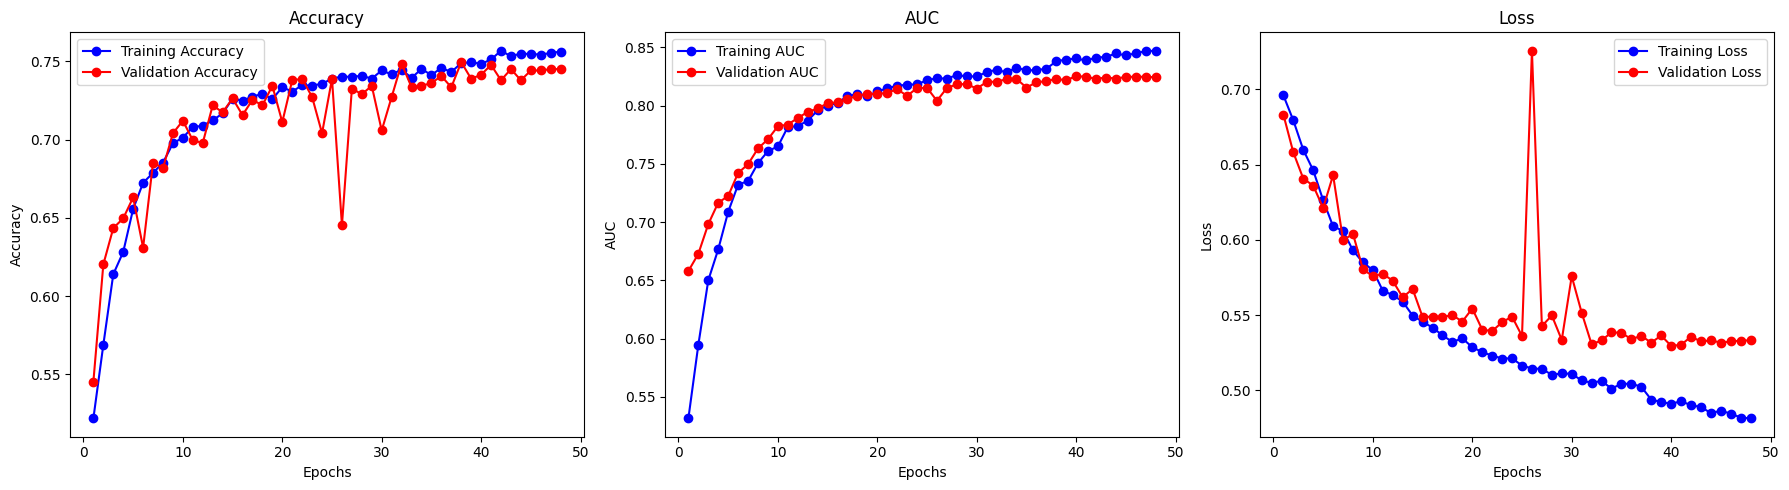

In [9]:
plot_training_metrics(history)

In [10]:
optimal_threshold = find_optimal_threshold(y_val, model.predict(X_val))

# Fai la predizione sul set di test
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > optimal_threshold).astype("int32")

36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step
Soglia ottimale: 0.516
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


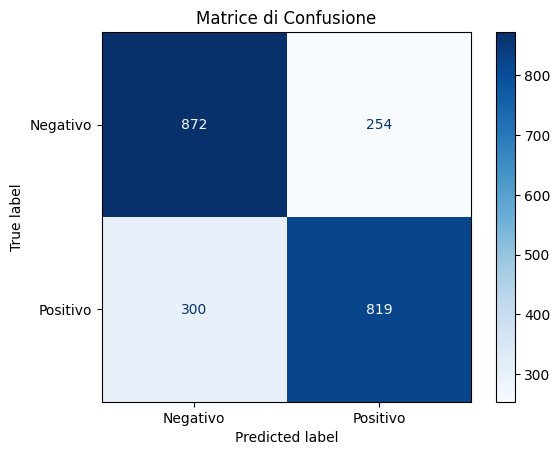

In [13]:
from sklearn.metrics import confusion_matrix, classification_report

#Calcoliamo la matrice di confusione e la visualizziamo
cm = confusion_matrix(y_test, y_pred_classes)
show_confusion_matrix(cm)

In [14]:
def find_threshold_for_min_recall(y_true, y_pred_proba, min_recall=0.80):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    valid_indices = [i for i, val in enumerate(tpr) if val >= min_recall]
    if not valid_indices:
        print("Nessuna soglia raggiunge la recall minima richiesta.")
        return None
    # Prendi la soglia con il più basso FPR tra quelli con recall >= min_recall
    best_idx = min(valid_indices, key=lambda i: fpr[i])
    threshold = thresholds[best_idx]
    print(f"Soglia con recall >= {min_recall}: {threshold:.3f}")
    return threshold

In [15]:
#Facciamo le predizioni
y_pred_proba_val = model.predict(X_val).flatten()

#Troviamo la soglia ottimale
optimal_threshold_min_rec = find_threshold_for_min_recall(y_val, y_pred_proba_val)

# Applica soglia ottimale per binarizzare le predizioni
y_pred_proba_test = model.predict(X_test).flatten()
y_pred_binary = (y_pred_proba_test >= optimal_threshold_min_rec).astype(int)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Soglia con recall >= 0.8: 0.433
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


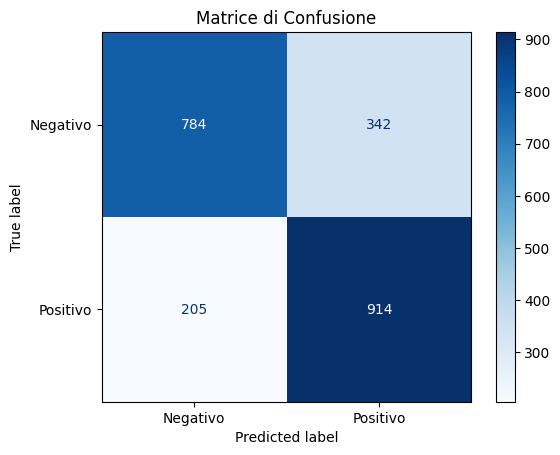

In [16]:
#Calcoliamo la matrice di confusione e la visualizziamo
cm = confusion_matrix(y_test, y_pred_binary)
show_confusion_matrix(cm)

In [17]:
#Vediamo i risultati
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

acc = accuracy_score(y_test, y_pred_binary)
auc = roc_auc_score(y_test, y_pred_binary)

print(f"Accuracy: {acc:.3f}")
print(f"AUC: {auc:.3f}")

class_report1 = classification_report(y_test, y_pred_binary, target_names=["Negativo", "Positivo"])
print(class_report1)
class_report1 = classification_report(y_test, y_pred_binary, output_dict=True )

Accuracy: 0.756
AUC: 0.757
              precision    recall  f1-score   support

    Negativo       0.79      0.70      0.74      1126
    Positivo       0.73      0.82      0.77      1119

    accuracy                           0.76      2245
   macro avg       0.76      0.76      0.76      2245
weighted avg       0.76      0.76      0.76      2245



# Modello intermedio

In [35]:
def build_cnn(input_shape=(88, 64, 12)):
    inputs = tf.keras.Input(shape=input_shape)

    # Logarithmic spectrogram
    x = LightLogSpectrogram()(inputs)  # shape: [batch, time, freq, 12]

    # Block 1
    x = tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    # Block 2
    x = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    # Block 3
    x = tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    # Global Pooling
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    # Fully Connected
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)  # For binary classification

    model = tf.keras.Model(inputs, outputs)
    return model


In [36]:
# Compilazione del modello
model = build_cnn(input_shape=(2800, 12))
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc')]
)

model.summary()

# Callback: early stopping e salvataggio del modello migliore
callbacks = make_callback("intermediate_CNN")

# Training
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=30,
    callbacks=callbacks
)

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 2800, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ light_log_spectrogram_11        │ (None, 88, 64, 12)     │             0 │
│ (LightLogSpectrogram)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 88, 64, 32)     │         3,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 88, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 44, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 44, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 44, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 44, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 22, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 22, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 22, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 22, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 11, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 11, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,057 (410.38 KB)

 Trainable params: 104,609 (408.63 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5901 - auc: 0.6300 - loss: 0.6770
Epoch 1: val_auc improved from -inf to 0.72746, saving model to intermediate_CNN_best_model.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.5902 - auc: 0.6303 - loss: 0.6769 - val_accuracy: 0.6078 - val_auc: 0.7275 - val_loss: 0.6625 - learning_rate: 0.0010
Epoch 2/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6808 - auc: 0.7424 - loss: 0.5995
Epoch 2: val_auc improved from 0.72746 to 0.78063, saving model to intermediate_CNN_best_model.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6808 - auc: 0.7425 - loss: 0.5994 - val_accuracy: 0.6622 - val_auc: 0.7806 - val_loss: 0.6062 - learning_rate: 0.0010
Epoch 3/50
261/262 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7100 - auc: 0.7903 - loss: 0.5519
Epoch 3: val_auc improved from 0.78063 to 0.81986, saving model to intermediate_CNN_best_model.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accu

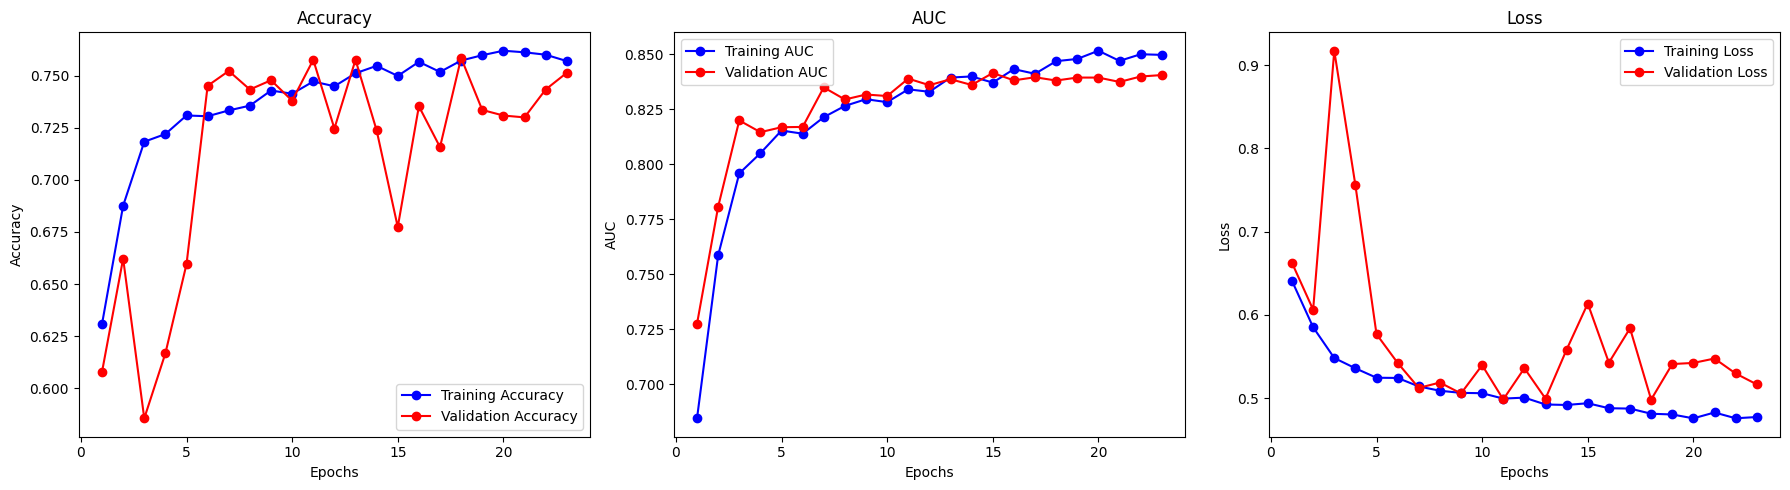

In [37]:
plot_training_metrics(history)

In [39]:
#Facciamo le predizioni
y_pred_proba_val = model.predict(X_val).flatten()

#Troviamo la soglia ottimale
optimal_threshold_min_rec = find_threshold_for_min_recall(y_val, y_pred_proba_val)

# Applica soglia ottimale per binarizzare le predizioni
y_pred_proba_test = model.predict(X_test).flatten()
y_pred_binary = (y_pred_proba_test >= optimal_threshold_min_rec).astype(int)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Soglia con recall >= 0.8: 0.700
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


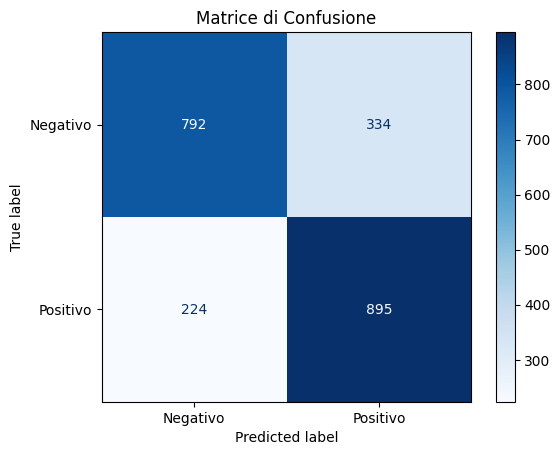

In [40]:
#Calcoliamo la matrice di confusione e la visualizziamo
cm = confusion_matrix(y_test, y_pred_binary)
show_confusion_matrix(cm)